In [17]:
import pandas 
import numpy as np
import moments 
import dpluspy 
import scipy
from collections import defaultdict

In [18]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)
plt.rcParams['legend.title_fontsize'] = 'small'

In [19]:
# Load data, models

datasets = ["Bherer", "ZhouJHS"]
model_names = [
    "alt_kho",
    "alt_mbu",
    "alt_yor",
    "cha_kho",
    "cha_mbu",
    "cha_yor",
    "vin_kho",
    "vin_mbu",
    "vin_yor",
]

u = 1.3e-8

datas = {}
models = {}
params = {}

for dataset in datasets:
    data_file = f"../../../analyses/recombination_maps/stats/subset_{dataset}.pkl"
    for model in model_names:
        graph = f"results/{model}_{dataset}.yaml"
        param_file = f"models/{model}_params.yaml"
        data = dpluspy.inference.load_bootstrap_reps(
            data_file, graph=graph, return_dict=True)
        datas[(model, dataset)] = data
        models[(model, dataset)] = dpluspy.inference.compute_bin_stats(
            graph, sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
        params[(model, dataset)] = dpluspy.inference._load_params(
            graph, param_file)

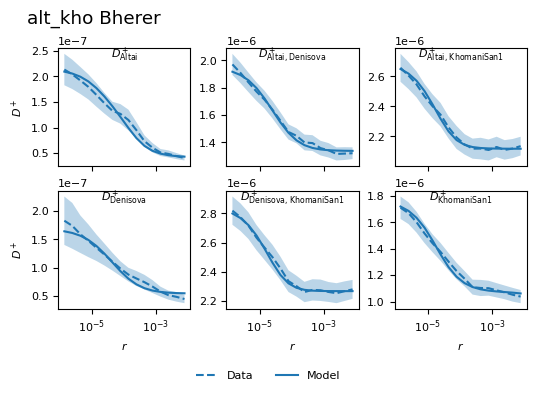

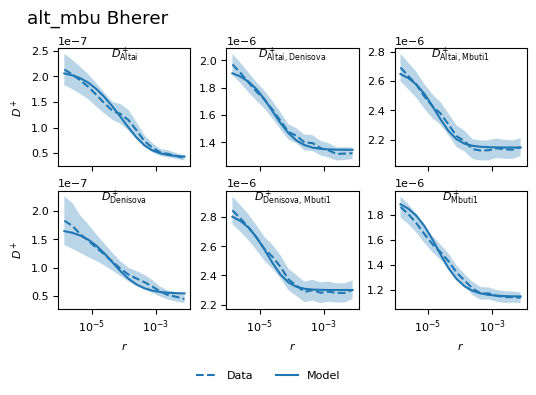

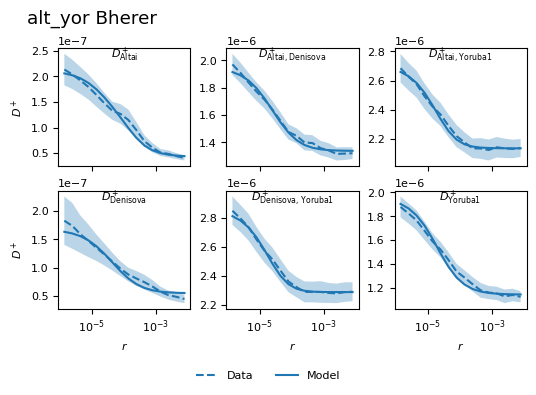

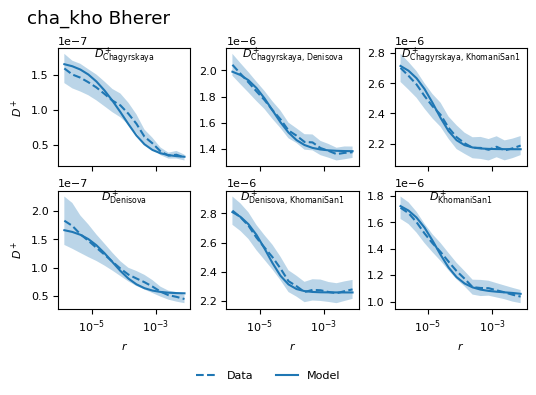

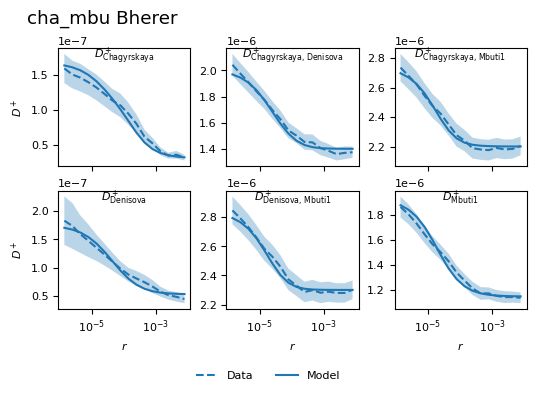

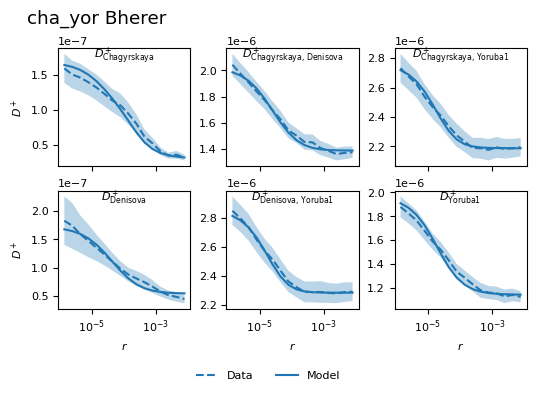

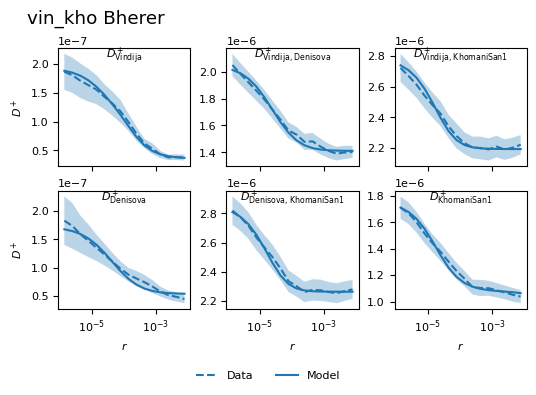

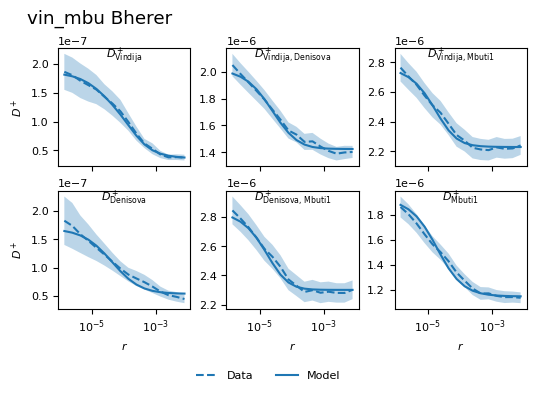

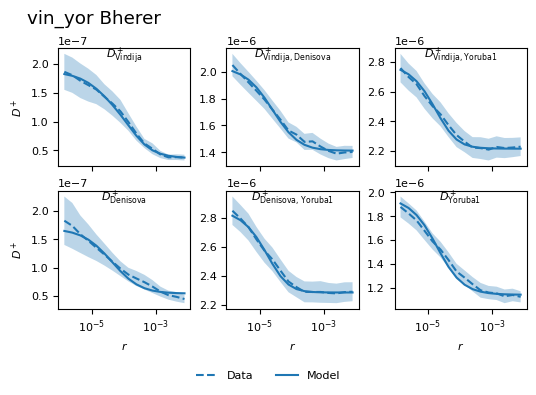

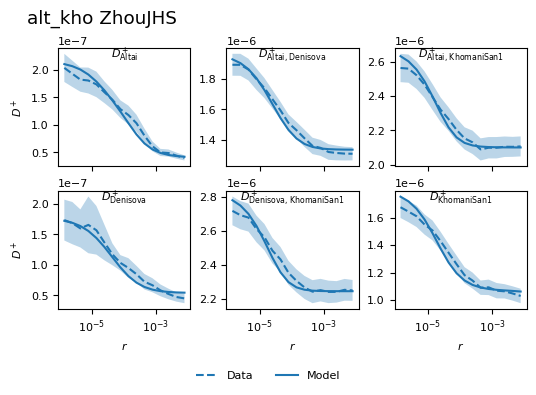

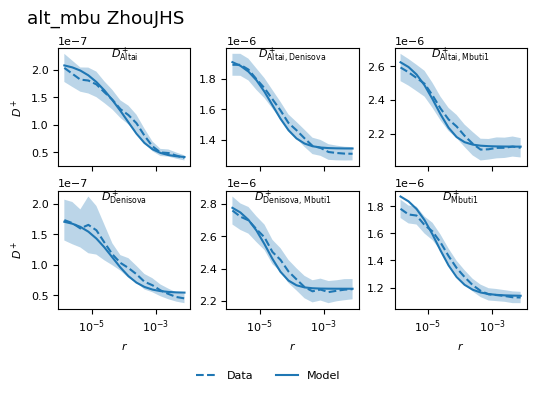

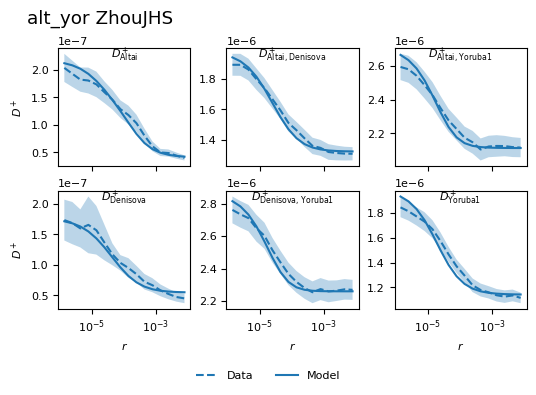

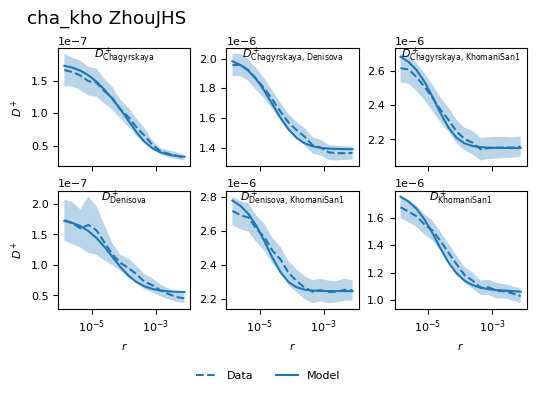

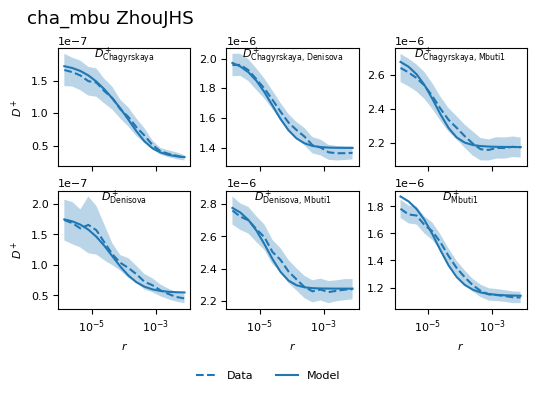

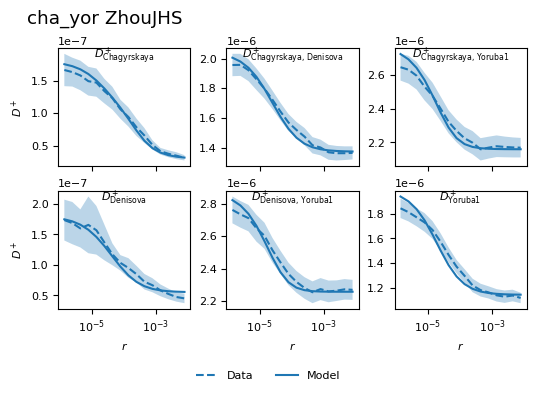

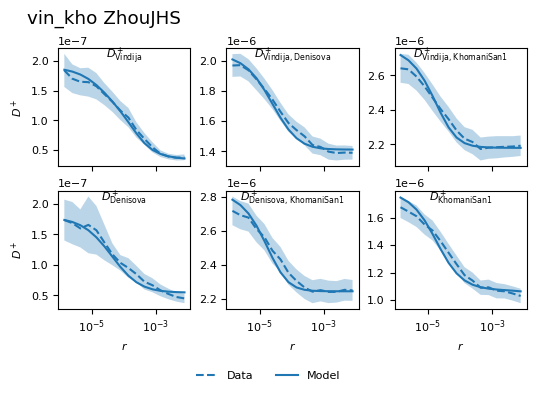

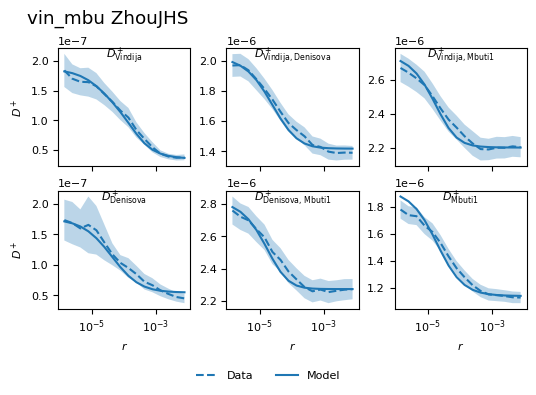

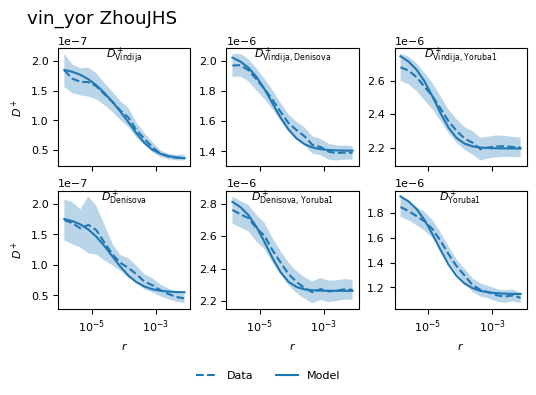

In [47]:
# Make some figures

for dataset in datasets:
    for model in model_names:
        dpluspy.plotting.plot_D_plus_curves(
            models=models[(model, dataset)],
            means=datas[(model, dataset)]["means"],
            varcovs=datas[(model, dataset)]["varcovs"],
            bins=datas[(model, dataset)]["bins"],
            pop_ids=datas[(model, dataset)]["pop_ids"],
            out=f"figures/best_fit_{model}_{dataset}.pdf",
            show=False, ax_size=1.75, cols=3,
            title=f"{model} {dataset}"
        )

In [27]:
# Compute uncerts

uncerts_tbl = []
params_tbl = []

for dataset in ["Bherer"]:
    for model in model_names:
        data = datas[(model, dataset)]
        graph = f"results/{model}_{dataset}.yaml"
        param_file = f"models/{model}_params.yaml"
        pnames, pvals, uncerts = dpluspy.uncerts.GIM_uncerts(
            graph,
            param_file,
            data["means"],
            data["varcovs"],
            bootreps=data["replicates"],
            pop_ids=data["pop_ids"],
            bins=data["bins"],
            u=u,
            verbose=False
        )
        print((model, dataset))

        params_dict = {"model": [f"{model}_{dataset}"]}
        params_dict.update(
            {pname: [pval] for pname, pval in zip(pnames, pvals)})
        params_tbl.append(pandas.DataFrame(params_dict))

        uncerts_dict = {"model": [f"{model}_{dataset}"]}
        uncerts_dict.update(
            {pname: [uncert] for pname, uncert in zip(pnames, uncerts)})
        uncerts_tbl.append(pandas.DataFrame(uncerts_dict))
            
    df_gim = pandas.concat(uncerts_tbl)
    df_mle = pandas.concat(params_tbl)
    df_gim.to_csv("GIM_uncerts.csv", index=False)
    df_mle.to_csv("best_fit_params.csv", index=False)

('alt_kho', 'Bherer')
('alt_mbu', 'Bherer')
('alt_yor', 'Bherer')
('cha_kho', 'Bherer')
('cha_mbu', 'Bherer')
('cha_yor', 'Bherer')
('vin_kho', 'Bherer')
('vin_mbu', 'Bherer')
('vin_yor', 'Bherer')


In [30]:
print(df_gim.columns)
print(df_gim)

Index(['model', 'T_NDH', 'T_ND', 'T_pHN', 'N_Anc', 'N_Kho0', 'N_KhoBot',
       'N_ND', 'N_Den', 'N_Alt', 'p_HN', 'N_Mbu', 'N_Yor', 'N_Cha', 'N_Vin'],
      dtype='object')
            model         T_NDH          T_ND         T_pHN       N_Anc  \
0  alt_kho_Bherer   7754.871209   3641.237702  58947.228587  241.082644   
0  alt_mbu_Bherer  24484.066324  18157.159038  42677.610537  433.875807   
0  alt_yor_Bherer   6185.235232   3875.419642  47176.871614  226.386286   
0  cha_kho_Bherer   3914.121356   3080.822625  74769.285734  220.405505   
0  cha_mbu_Bherer  23975.505481  30314.296904  45183.739711  428.165886   
0  cha_yor_Bherer   7603.175166   4414.332617  43032.874718  237.893399   
0  vin_kho_Bherer   7373.014622   4312.724369  31349.684115  241.123683   
0  vin_mbu_Bherer  42391.079727  38465.437003  23566.983589  689.801914   
0  vin_yor_Bherer   5793.853959   3944.099443  26383.265786  225.169476   

        N_Kho0  N_KhoBot        N_ND       N_Den       N_Alt      p_HN  \
0 

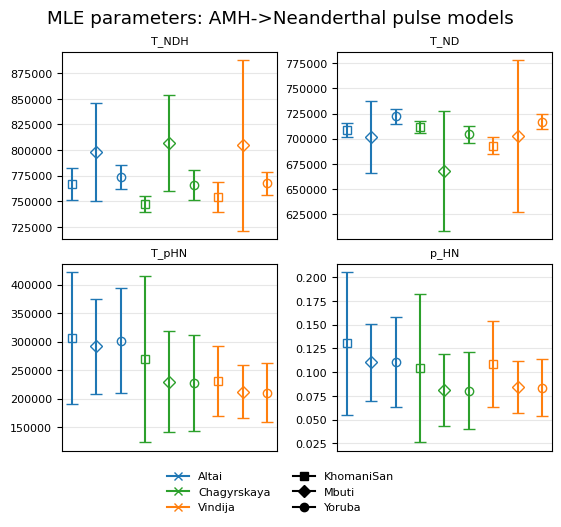

In [46]:
fig, axs = plt.subplots(2, 2, figsize=(5.5, 4.5), layout="constrained",
    sharex=True)
axs = axs.flat

for ax in axs:
    ax.grid(alpha=0.3)

plot_params = ["T_NDH", "T_ND", "T_pHN", "p_HN"]

for ii, param in enumerate(plot_params):
    ax = axs[ii]
    ax.xaxis.set_visible(False)
    ax.set_title(param)
    for jj, model in enumerate(df_mle["model"]):
        neanderthal, african, _ = model.split("_")
        color = {"alt": "tab:blue", "vin": "tab:orange", 
            "cha": "tab:green"}[neanderthal]
        marker = {"yor": "o", "kho": "s", "mbu": "D"}[african]
        ax.errorbar(
            [jj], 
            df_mle[df_mle["model"] == model][param], 
            yerr=1.96 * df_gim[df_gim["model"] == model][param], 
            fmt=marker,
            color=color,
            markerfacecolor="none",
            capsize=4
        )

from matplotlib.lines import Line2D
symbols = [
    Line2D([0], [0], color="tab:blue", marker="x"),
    Line2D([0], [0], color="tab:green", marker="x"),
    Line2D([0], [0], color="tab:orange", marker="x"),
    Line2D([0], [0], color="black", marker="s"),
    Line2D([0], [0], color="black", marker="D"),
    Line2D([0], [0], color="black", marker="o"),
]
handles = [
    "Altai",
    "Chagyrskaya",
    "Vindija", 
    "KhomaniSan",
    "Mbuti",
    "Yoruba",
]
fig.legend(symbols, handles, framealpha=0, loc="lower center", ncols=2,
    bbox_to_anchor=[0.5, -0.15])

fig.suptitle("MLE parameters: AMH->Neanderthal pulse models")
plt.savefig("figures/parameter_uncerts.pdf")